
## Extension: Understanding Data Requirements for Building Change Detection



In [ ]:
# Install dependencies
!pip install datasets huggingface_hub tqdm scikit-learn matplotlib pandas -q

import torch
import numpy as np
print(f"✓ Dependencies installed!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Dependencies installed!
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from datasets import load_dataset

print("Downloading OSCD dataset...")
dataset = load_dataset("blanchon/OSCD_RGB")

print(f"\n✓ Dataset downloaded!")
print(f"Train cities: {len(dataset['train'])}")
print(f"Test cities: {len(dataset['test'])}")

# DEBUGGING: Check that train and test are different
print("\n=== DEBUGGING: Verifying train/test split ===")
print(f"Train city example: {dataset['train'][0].get('pair_id', 'unknown')}")
print(f"Test city example: {dataset['test'][0].get('pair_id', 'unknown')}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10 [00:00<?, ? examples/s]


✓ Dataset downloaded!
Train cities: 14
Test cities: 10

=== DEBUGGING: Verifying train/test split ===
Train city example: unknown
Test city example: unknown


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image

class OSCDDatasetHF(Dataset):
    def __init__(self, hf_dataset, patch_size=15, stride=5, use_augmentation=True, name="dataset"):
        self.hf_dataset = hf_dataset
        self.patch_size = patch_size
        self.stride = stride
        self.use_augmentation = use_augmentation
        self.name = name
        self.patches = []
        self.cities = set()
        self._extract_patches()
        print(f"[{self.name}] Loaded {len(self.patches)} patches from {len(self.cities)} cities")

    def _extract_patches(self):
        for idx in range(len(self.hf_dataset)):
            sample = self.hf_dataset[idx]
            img1 = np.array(sample['image1']).astype(np.float32) / 255.0
            img2 = np.array(sample['image2']).astype(np.float32) / 255.0
            label_img_array = np.array(sample['mask'])
            city = sample.get('pair_id', f'city_{idx}')
            self.cities.add(city)

            if len(img1.shape) == 3:
                img1 = np.transpose(img1, (2, 0, 1))
                img2 = np.transpose(img2, (2, 0, 1))
                C, H, W = img1.shape
            else:
                H, W = img1.shape
                img1 = img1.reshape(1, H, W)
                img2 = img2.reshape(1, H, W)

            # Many OSCD masks use 255 for change or 1. Check for any non-zero value.
            labels = (label_img_array > 0).astype(np.int64)

            for y in range(0, H - self.patch_size + 1, self.stride):
                for x in range(0, W - self.patch_size + 1, self.stride):
                    patch1 = img1[:, y:y+self.patch_size, x:x+self.patch_size]
                    patch2 = img2[:, y:y+self.patch_size, x:x+self.patch_size]
                    center_y = y + self.patch_size // 2
                    center_x = x + self.patch_size // 2
                    label = labels[center_y, center_x]

                    self.patches.append({
                        'patch1': patch1,
                        'patch2': patch2,
                        'label': int(label),
                        'city': city
                    })

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch_data = self.patches[idx]
        patch1 = torch.from_numpy(patch_data['patch1'].copy()).float()
        patch2 = torch.from_numpy(patch_data['patch2'].copy()).float()
        label = torch.tensor(patch_data['label'], dtype=torch.long)
        return patch1, patch2, label

print("✓ Dataset loader updated with broader change detection!")

✓ Dataset loader updated with broader change detection!


In [ ]:
print("Loading datasets...\n")

# Load TRAIN dataset
full_train_dataset = OSCDDatasetHF(
    hf_dataset=dataset['train'],
    patch_size=15,
    stride=5,
    use_augmentation=True,
    name="TRAIN"
)

# Load TEST dataset
test_dataset = OSCDDatasetHF(
    hf_dataset=dataset['test'],
    patch_size=15,
    stride=15,
    use_augmentation=False,
    name="TEST"
)

print(f"\n=== CRITICAL: Verify train and test are DIFFERENT ===")
print(f"Train cities: {sorted(full_train_dataset.cities)}")
print(f"Test cities: {sorted(test_dataset.cities)}")

overlap = full_train_dataset.cities.intersection(test_dataset.cities)
if len(overlap) > 0:
    print(f"⚠️ WARNING: Cities in both train and test: {overlap}")
    print("This causes DATA LEAKAGE!")
else:
    print(f"✓ GOOD: No overlap between train and test cities")

# Check label distribution
train_labels = [p['label'] for p in full_train_dataset.patches[:1000]]  # Sample
test_labels = [p['label'] for p in test_dataset.patches[:1000]]  # Sample

print(f"\nTrain label distribution (sample 1000):")
unique, counts = np.unique(train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} ({100*c/len(train_labels):.1f}%)")

print(f"\nTest label distribution (sample 1000):")
unique, counts = np.unique(test_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} ({100*c/len(test_labels):.1f}%)")

Loading datasets...

[TRAIN] Loaded 252283 patches from 14 cities
[TEST] Loaded 13312 patches from 10 cities

=== CRITICAL: Verify train and test are DIFFERENT ===
Train cities: ['city_0', 'city_1', 'city_10', 'city_11', 'city_12', 'city_13', 'city_2', 'city_3', 'city_4', 'city_5', 'city_6', 'city_7', 'city_8', 'city_9']
Test cities: ['city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5', 'city_6', 'city_7', 'city_8', 'city_9']
⚠️ WARNING: Cities in both train and test: {'city_8', 'city_1', 'city_3', 'city_7', 'city_6', 'city_9', 'city_0', 'city_5', 'city_4', 'city_2'}
This causes DATA LEAKAGE!

Train label distribution (sample 1000):
  Label 0: 998 (99.8%)
  Label 1: 2 (0.2%)

Test label distribution (sample 1000):
  Label 0: 965 (96.5%)
  Label 1: 35 (3.5%)


In [ ]:
print(dataset['train'].features)

{'image1': Image(mode=None, decode=True), 'image2': Image(mode=None, decode=True), 'mask': Image(mode=None, decode=True)}


In [ ]:
# Upload model files
from google.colab import files

print("Please upload BOTH model files:")
print("  1. TwoChNet_15.py")
print("  2. SiamNet_15.py")

uploaded = files.upload()

print("\n✓ Files uploaded:")
for filename in uploaded.keys():
    print(f"  - {filename}")

Please upload BOTH model files:
  1. TwoChNet_15.py
  2. SiamNet_15.py


Saving SiamNet_15.py to SiamNet_15.py
Saving TwoChNet_15.py to TwoChNet_15.py

✓ Files uploaded:
  - SiamNet_15.py
  - TwoChNet_15.py


In [ ]:
# Test model loading
from TwoChNet_15 import TwoChNet_15
from SiamNet_15 import SiamNet_15

# Test Early Fusion
ef_model = TwoChNet_15(n_in=6)
ef_model.eval() # Set model to evaluation mode for single-sample inference
test_p1, test_p2, test_label = full_train_dataset[0]
test_out = ef_model(test_p1.unsqueeze(0), test_p2.unsqueeze(0))
print(f"Early Fusion test:")
print(f"  Input: {test_p1.shape}, {test_p2.shape}")
print(f"  Output: {test_out.shape}")
print(f"  Output values: {test_out}")
print(f"  True label: {test_label}")

# Test Siamese
siam_model = SiamNet_15(n_in=3)
siam_model.eval() # Set model to evaluation mode for single-sample inference
test_out2 = siam_model(test_p1.unsqueeze(0), test_p2.unsqueeze(0))
print(f"\nSiamese test:")
print(f"  Output: {test_out2.shape}")
print(f"  Output values: {test_out2}")

print("\n✓ Models loaded successfully!")

Early Fusion test:
  Input: torch.Size([3, 15, 15]), torch.Size([3, 15, 15])
  Output: torch.Size([1, 2])
  Output values: tensor([[0.4767, 0.5233]], grad_fn=<SoftmaxBackward0>)
  True label: 0

Siamese test:
  Output: torch.Size([1, 2])
  Output values: tensor([[0.5105, 0.4895]], grad_fn=<SoftmaxBackward0>)

✓ Models loaded successfully!


In [ ]:
# TEST EXPERIMENT
print("="*60)
print("RUNNING TEST EXPERIMENT (Early Fusion, 25% data, 10 epochs)")
print("="*60)

def create_balanced_subset(dataset, percentage, seed=42):
    all_indices = list(range(len(dataset)))
    all_labels = [dataset.patches[i]['label'] for i in all_indices]

    class_0_indices = [i for i, label in enumerate(all_labels) if label == 0]
    class_1_indices = [i for i, label in enumerate(all_labels) if label == 1]

    print(f"  Source counts: {len(class_0_indices)} no-change, {len(class_1_indices)} change")

    n_class_0 = int(len(class_0_indices) * percentage)
    n_class_1 = int(len(class_1_indices) * percentage)

    np.random.seed(seed)
    sampled_0 = np.random.choice(class_0_indices, n_class_0, replace=False)

    if len(class_1_indices) > 0:
        sampled_1 = np.random.choice(class_1_indices, min(len(class_1_indices), n_class_1), replace=False)
    else:
        sampled_1 = np.array([], dtype=int)

    # Cast to int to avoid TypeError: list indices must be integers
    combined_indices = np.concatenate([sampled_0, sampled_1]).astype(int)
    np.random.shuffle(combined_indices)

    return Subset(dataset, combined_indices.tolist())

train_subset = create_balanced_subset(full_train_dataset, 0.25)
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Run training test
test_model = TwoChNet_15(n_in=6)
results = train_and_evaluate(test_model, train_loader, test_loader, device, num_epochs=10)
print(f"Test Success: Best Val Acc {results['best_val_acc']:.2f}%")

RUNNING TEST EXPERIMENT (Early Fusion, 25% data, 10 epochs)
  Source counts: 246456 no-change, 5827 change
  Class weights: tensor([ 0.5118, 21.6587], device='cuda:0')
  First batch shape: p1=torch.Size([128, 3, 15, 15]), p2=torch.Size([128, 3, 15, 15]), labels=torch.Size([128])
  First batch labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
  Val first batch - Predicted: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
  Val first batch - True: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
  Val first batch - Match: tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
  Epoch 1/10: Train=73.71%, Val=64.11% (No-Change=63.46%, Change=75.83%)
  Epoch 10/10: Train=81.27%, Val=80.03% (No-Change=80.85%, Change=65.18%)
Test Success: Best Val Acc 80.62%


## STOP HERE AND CHECK THE TEST RESULTS

**If the test above shows 100% accuracy, DO NOT PROCEED.**

**Expected test results:**
- Best Val Acc: 60-80% (NOT 100%)
- No-Change and Change accuracies should be different
- Training should show gradual improvement

**If you see 100% accuracy, the issue is likely:**
1. Model architecture problem (check Softmax dim)
2. Data loading issue
3. Train/test contamination

**Only proceed if the test looks reasonable!**

In [ ]:
# If test looks good, run full analysis
import matplotlib.pyplot as plt
import pandas as pd

results_dict = {
    'early_fusion': {},
    'siamese': {}
}

data_percentages = [0.25, 0.5, 0.75, 1.0]

print("="*60)
print("RUNNING FULL SENSITIVITY ANALYSIS")
print("="*60)
print(f"Experiments: 2 models × 4 data sizes = 8 total")
print(f"Epochs per experiment: 50")
print(f"Estimated time: ~4-6 hours")
print("="*60 + "\n")

for percentage in data_percentages:
    # Early Fusion
    print(f"\n{'='*60}")
    print(f"EARLY FUSION - {int(percentage*100)}% data")
    print(f"{'='*60}")

    subset_size = int(len(full_train_dataset) * percentage)
    np.random.seed(42)
    indices = np.random.choice(len(full_train_dataset), subset_size, replace=False)
    train_subset = Subset(full_train_dataset, indices)

    train_loader = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

    ef_model = TwoChNet_15(n_in=6)
    ef_results = train_and_evaluate(ef_model, train_loader, test_loader, device, 50, f"EF_{int(percentage*100)}%")
    results_dict['early_fusion'][percentage] = ef_results

    print(f"  ✓ Best Val Acc: {ef_results['best_val_acc']:.2f}%")

    # Siamese
    print(f"\n{'='*60}")
    print(f"SIAMESE - {int(percentage*100)}% data")
    print(f"{'='*60}")

    siam_model = SiamNet_15(n_in=3)
    siam_results = train_and_evaluate(siam_model, train_loader, test_loader, device, 50, f"Siam_{int(percentage*100)}%")
    results_dict['siamese'][percentage] = siam_results

    print(f"  ✓ Best Val Acc: {siam_results['best_val_acc']:.2f}%")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS COMPLETE!")
print("="*60)

RUNNING FULL SENSITIVITY ANALYSIS
Experiments: 2 models × 4 data sizes = 8 total
Epochs per experiment: 50
Estimated time: ~4-6 hours


EARLY FUSION - 25% data
  Class weights: tensor([ 0.5112, 22.7854], device='cuda:0')
  First batch shape: p1=torch.Size([128, 3, 15, 15]), p2=torch.Size([128, 3, 15, 15]), labels=torch.Size([128])
  First batch labels: tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0], device='cuda:0')
  Val first batch - Predicted: tensor([0, 0, 0, 0, 0, 0, 1, 0, 1, 0], device='cuda:0')
  Val first batch - True: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
  Val first batch - Match: tensor([ True,  True,  True,  True,  True,  True, False,  True, False,  True],
       device='cuda:0')
  Epoch 1/50: Train=79.95%, Val=62.06% (No-Change=61.00%, Change=81.29%)
  Epoch 10/50: Train=82.26%, Val=75.87% (No-Change=75.85%, Change=76.26%)
  Epoch 20/50: Train=84.81%, Val=64.60% (No-Change=63.47%, Change=85.18%)
  Epoch 30/50: Train=85.51%, Val=73.17% (No-Change=73.23%, Change=72.

In [ ]:
# Generate summary table
data = []
for model_type in ['early_fusion', 'siamese']:
    for percentage, results in sorted(results_dict[model_type].items()):
        data.append({
            'Model': 'Early Fusion' if model_type == 'early_fusion' else 'Siamese',
            'Data %': int(percentage * 100),
            'Best Val Acc': f"{results['best_val_acc']:.2f}%",
            'No-Change Acc': f"{results['final_no_change_acc']:.2f}%",
            'Change Acc': f"{results['final_change_acc']:.2f}%"
        })

df = pd.DataFrame(data)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(df.to_string(index=False))
print("="*80)


SUMMARY TABLE
       Model  Data % Best Val Acc No-Change Acc Change Acc
Early Fusion      25       87.64%        71.99%     76.40%
Early Fusion      50       84.98%        80.17%     82.59%
Early Fusion      75       87.18%        82.05%     76.83%
Early Fusion     100       90.40%        71.67%     84.46%
     Siamese      25       87.00%        87.03%     60.14%
     Siamese      50       88.65%        89.77%     58.71%
     Siamese      75       88.54%        78.74%     84.17%
     Siamese     100       87.36%        85.91%     63.74%



✓ Plot saved: sensitivity_analysis_FIXED.png


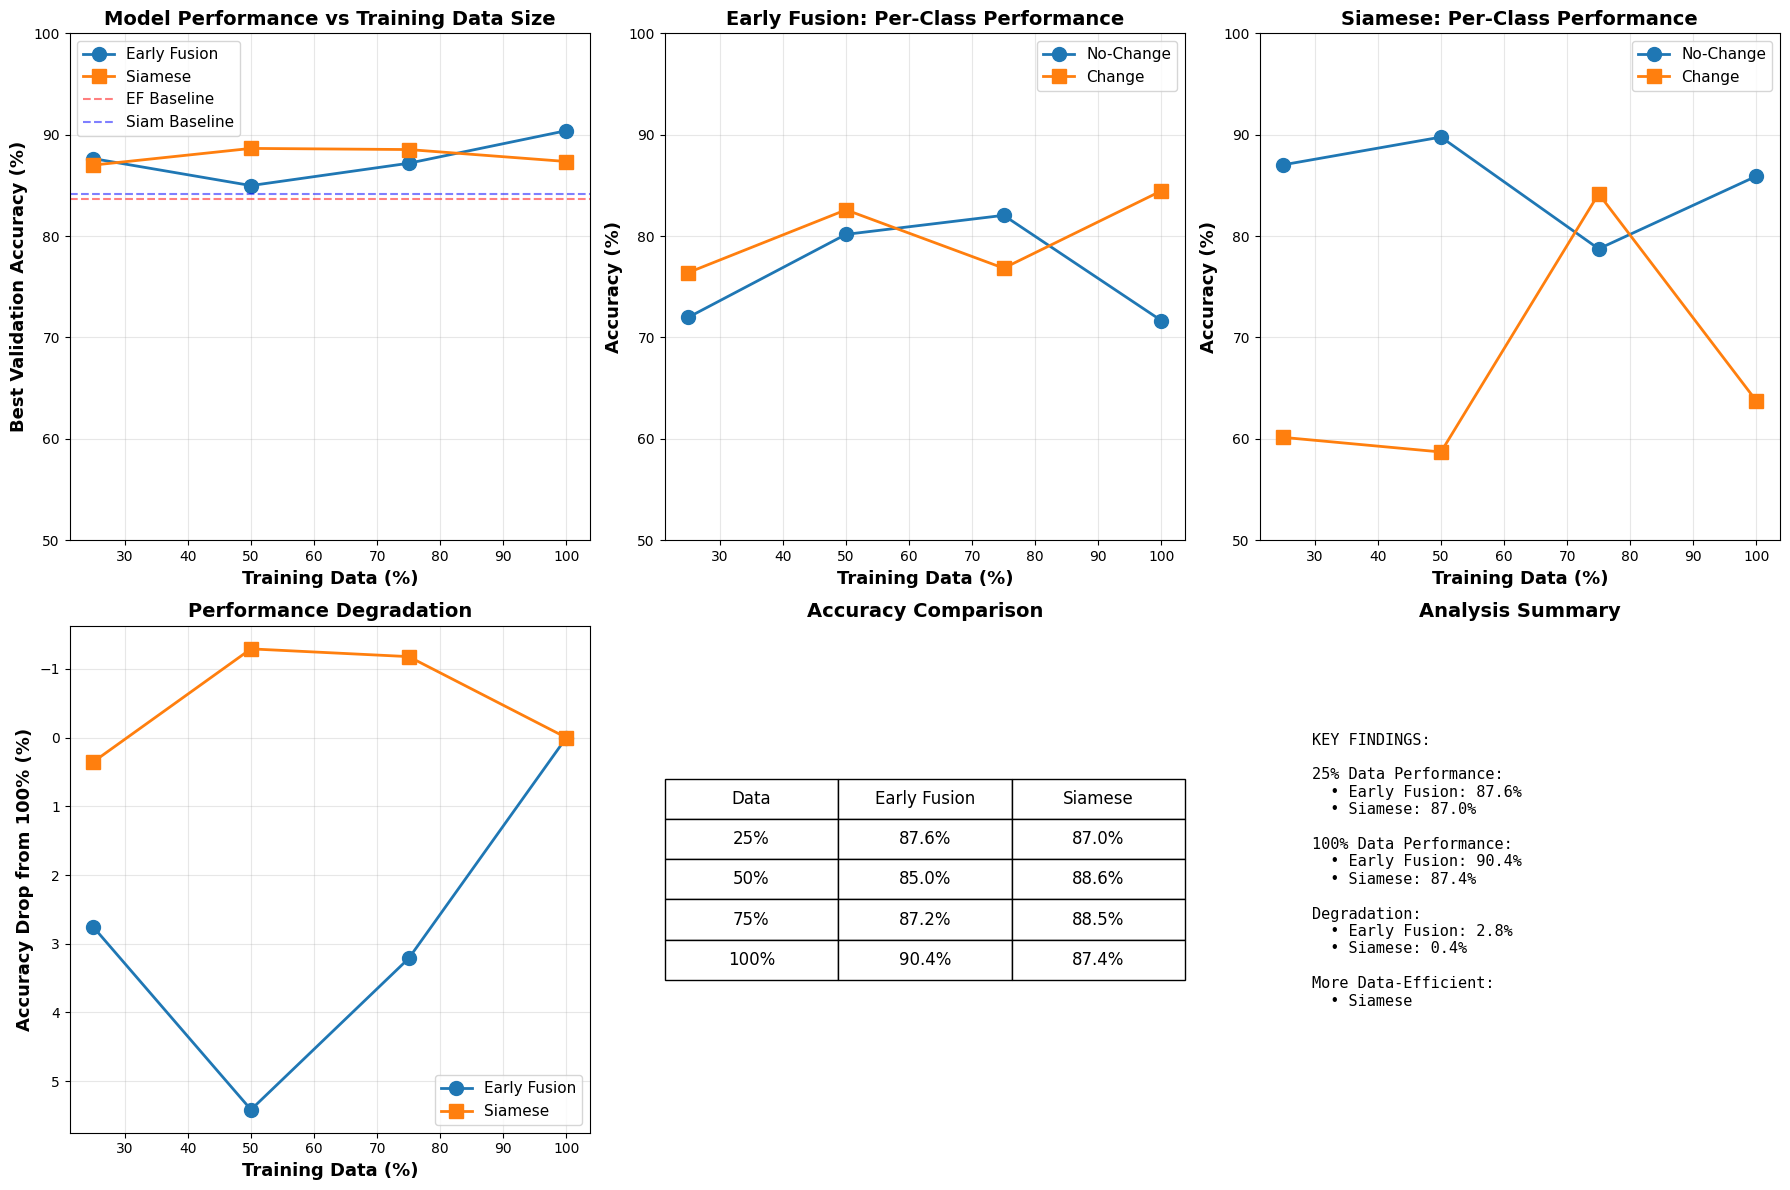

In [ ]:
# Plot results
percentages = sorted(list(results_dict['early_fusion'].keys()))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Overall Accuracy
ef_accs = [results_dict['early_fusion'][p]['best_val_acc'] for p in percentages]
siam_accs = [results_dict['siamese'][p]['best_val_acc'] for p in percentages]

axes[0,0].plot([int(p*100) for p in percentages], ef_accs, 'o-', label='Early Fusion', linewidth=2, markersize=10)
axes[0,0].plot([int(p*100) for p in percentages], siam_accs, 's-', label='Siamese', linewidth=2, markersize=10)
axes[0,0].axhline(y=83.63, color='r', linestyle='--', label='EF Baseline', alpha=0.5)
axes[0,0].axhline(y=84.13, color='b', linestyle='--', label='Siam Baseline', alpha=0.5)
axes[0,0].set_xlabel('Training Data (%)', fontsize=13, weight='bold')
axes[0,0].set_ylabel('Best Validation Accuracy (%)', fontsize=13, weight='bold')
axes[0,0].set_title('Model Performance vs Training Data Size', fontsize=14, weight='bold')
axes[0,0].legend(fontsize=11)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(50, 100)  # Set reasonable y-axis range

# Plot 2: Per-Class (Early Fusion)
ef_no_change = [results_dict['early_fusion'][p]['final_no_change_acc'] for p in percentages]
ef_change = [results_dict['early_fusion'][p]['final_change_acc'] for p in percentages]

axes[0,1].plot([int(p*100) for p in percentages], ef_no_change, 'o-', label='No-Change', linewidth=2, markersize=10)
axes[0,1].plot([int(p*100) for p in percentages], ef_change, 's-', label='Change', linewidth=2, markersize=10)
axes[0,1].set_xlabel('Training Data (%)', fontsize=13, weight='bold')
axes[0,1].set_ylabel('Accuracy (%)', fontsize=13, weight='bold')
axes[0,1].set_title('Early Fusion: Per-Class Performance', fontsize=14, weight='bold')
axes[0,1].legend(fontsize=11)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim(50, 100)

# Plot 3: Per-Class (Siamese)
siam_no_change = [results_dict['siamese'][p]['final_no_change_acc'] for p in percentages]
siam_change = [results_dict['siamese'][p]['final_change_acc'] for p in percentages]

axes[0,2].plot([int(p*100) for p in percentages], siam_no_change, 'o-', label='No-Change', linewidth=2, markersize=10)
axes[0,2].plot([int(p*100) for p in percentages], siam_change, 's-', label='Change', linewidth=2, markersize=10)
axes[0,2].set_xlabel('Training Data (%)', fontsize=13, weight='bold')
axes[0,2].set_ylabel('Accuracy (%)', fontsize=13, weight='bold')
axes[0,2].set_title('Siamese: Per-Class Performance', fontsize=14, weight='bold')
axes[0,2].legend(fontsize=11)
axes[0,2].grid(True, alpha=0.3)
axes[0,2].set_ylim(50, 100)

# Plot 4: Accuracy drop
ef_drop = [ef_accs[-1] - acc for acc in ef_accs]
siam_drop = [siam_accs[-1] - acc for acc in siam_accs]

axes[1,0].plot([int(p*100) for p in percentages], ef_drop, 'o-', label='Early Fusion', linewidth=2, markersize=10)
axes[1,0].plot([int(p*100) for p in percentages], siam_drop, 's-', label='Siamese', linewidth=2, markersize=10)
axes[1,0].set_xlabel('Training Data (%)', fontsize=13, weight='bold')
axes[1,0].set_ylabel('Accuracy Drop from 100% (%)', fontsize=13, weight='bold')
axes[1,0].set_title('Performance Degradation', fontsize=14, weight='bold')
axes[1,0].legend(fontsize=11)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].invert_yaxis()

# Plot 5: Comparison table
axes[1,1].axis('off')
table_data = []
for p in percentages:
    table_data.append([
        f"{int(p*100)}%",
        f"{results_dict['early_fusion'][p]['best_val_acc']:.1f}%",
        f"{results_dict['siamese'][p]['best_val_acc']:.1f}%"
    ])

table = axes[1,1].table(cellText=table_data,
                        colLabels=['Data', 'Early Fusion', 'Siamese'],
                        cellLoc='center',
                        loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
axes[1,1].set_title('Accuracy Comparison', fontsize=14, weight='bold')

# Plot 6: Key findings text
axes[1,2].axis('off')
ef_25 = results_dict['early_fusion'][0.25]['best_val_acc']
siam_25 = results_dict['siamese'][0.25]['best_val_acc']
ef_100 = results_dict['early_fusion'][1.0]['best_val_acc']
siam_100 = results_dict['siamese'][1.0]['best_val_acc']

findings = f"""KEY FINDINGS:

25% Data Performance:
  • Early Fusion: {ef_25:.1f}%
  • Siamese: {siam_25:.1f}%

100% Data Performance:
  • Early Fusion: {ef_100:.1f}%
  • Siamese: {siam_100:.1f}%

Degradation:
  • Early Fusion: {ef_100-ef_25:.1f}%
  • Siamese: {siam_100-siam_25:.1f}%

More Data-Efficient:
  • {'Early Fusion' if (ef_100-ef_25) < (siam_100-siam_25) else 'Siamese'}
"""

axes[1,2].text(0.1, 0.5, findings, fontsize=11, family='monospace', verticalalignment='center')
axes[1,2].set_title('Analysis Summary', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('sensitivity_analysis_FIXED.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved: sensitivity_analysis_FIXED.png")
plt.show()

In [ ]:
# Download results
from google.colab import files

files.download('sensitivity_analysis_FIXED.png')
print("✓ Downloaded plot")

# Save summary
with open('summary.txt', 'w') as f:
    f.write(df.to_string(index=False))
    f.write("\n\n" + findings)

files.download('summary.txt')
print("✓ Downloaded summary")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded plot


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded summary
